In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

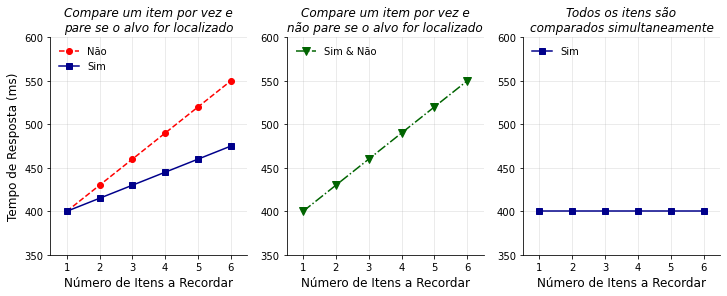

In [58]:
titles = ["Compare um item por vez e\npare se o alvo for localizado",
          "Compare um item por vez e\nnão pare se o alvo for localizado",
          "Todos os itens são\ncomparados simultaneamente"]

loads = np.array(list(range(1, 7)))

fig, axes = plt.subplots(1, 3, figsize = (12, 4))

no_responses_1 = 370 + 30 * loads
yes_responses_1 = 385 + 15 * loads

axes[0].plot(loads, no_responses_1, linestyle = "--",
             color = "red",
             marker = "o", label = "Não")
axes[0].plot(loads, yes_responses_1, linestyle = "-",
             color = "darkblue",
             marker = "s", label = "Sim")

no_responses_2 = 370 + 30 * loads
yes_responses_2 = 370 + 30 * loads

axes[1].plot(loads, no_responses_2, linestyle = "-.", 
             color = "darkgreen",
             marker = "v",
             markersize = 8,
             label = "Sim & Não")

yes_responses_3 = [400] * len(loads)

axes[2].plot(loads, yes_responses_3, linestyle = "-", 
             color = "darkblue",
             marker = "s", label = "Sim")


for i, ax in enumerate(axes):

    ax.set_title(titles[i], fontsize = 12,
                 fontstyle = "italic", color = "black")
    
    ax.set_ylim(350, 600)
    ax.set_xlim(0.5, 6.5)
    ax.set_xticks(loads)
    ax.set_xticklabels(loads)
    
    ax.set_xlabel("Número de Itens a Recordar", fontsize = 12)
    
    if i == 0:
        ax.set_ylabel("Tempo de Resposta (ms)", fontsize = 12)
    
    ax.spines[["top", "right"]].set_visible(False)
    
    ax.grid(alpha = 0.3)
    ax.legend(frameon = False, loc = "upper left")
    
plt.savefig("memory-scanning-task.jpg", dpi = 600, bbox_inches = "tight")

plt.show()

In [61]:
data = pd.read_csv(f"data/524086127_2025-12-30_11h08.46.731_Marcos Lima_alpha-span-task.csv", 
                 sep = ",")

data.shape

(146, 60)

In [62]:
data.columns

Index(['instructions.thisRepN', 'instructions.thisTrialN',
       'instructions.thisN', 'instructions.thisIndex',
       'memory_scanning_task_trials.thisRepN',
       'memory_scanning_task_trials.thisTrialN',
       'memory_scanning_task_trials.thisN',
       'memory_scanning_task_trials.thisIndex',
       'memory_scanning_task_digit.thisRepN',
       'memory_scanning_task_digit.thisTrialN',
       'memory_scanning_task_digit.thisN',
       'memory_scanning_task_digit.thisIndex', 'welcome_msg.started',
       'welcome_next.started', 'welcome_resp.started', 'participant_code',
       'instr_msg.started', 'previous.started', 'next.started',
       'instr_resp.started', 'new_trial_prompt.started',
       'new_trial_resp.started', 'to_be_remembered.started',
       'prompt_task.started', 'positive_button.started',
       'negative_button.started', 'positive.started', 'negative.started',
       'prompt_recall.started', 'resp.started', 'my_digit', 'load',
       'trial_type', 'probe', 'sequ

In [66]:
new_data = data[["load", "trial_type", "probe", "position", "resp.corr", "resp.rt"]].dropna()

rt_means = (
    new_data
    .groupby(["load", "trial_type"])["resp.rt"]
    .mean()
    .reset_index()
)

rt_means

,load,trial_type,resp.rt
0,1.0,negative,0.411771
1,1.0,positive,0.371479
2,2.0,negative,0.487035
3,2.0,positive,0.435387
4,3.0,negative,0.480660
5,3.0,positive,0.541914
6,4.0,negative,0.519998
7,4.0,positive,0.489484
8,5.0,negative,0.657733
9,5.0,positive,0.542157


In [67]:
negative = rt_means[rt_means["trial_type"] == "negative"]
positive = rt_means[rt_means["trial_type"] == "positive"]

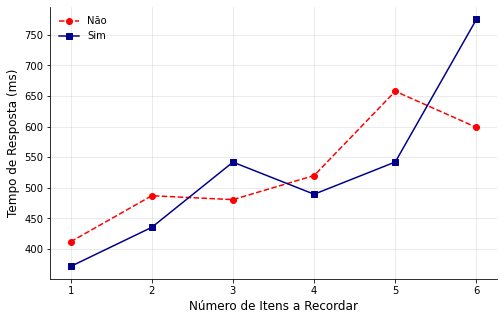

In [80]:
fig, ax = plt.subplots(1, 1, figsize = (8, 5))

ax.plot(negative["load"], negative["resp.rt"] * 1000, linestyle = "--",
             color = "red",
             marker = "o", label = "Não")

ax.plot(positive["load"], positive["resp.rt"] * 1000, linestyle = "-",
             color = "darkblue",
             marker = "s", label = "Sim")

ax.set_xlabel("Número de Itens a Recordar", fontsize = 12)
ax.set_ylabel("Tempo de Resposta (ms)", fontsize = 12)
    

ax.grid(alpha = 0.3)
ax.legend(frameon = False)
ax.spines[["top", "right"]].set_visible(False)

plt.savefig("memory-scanning-task-data.jpg", dpi = 600, bbox_inches = "tight")

plt.show()